In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point
from shapely.ops import transform
import cartopy.feature as cfeature
import matplotlib.patheffects as pe
import textwrap
import matplotlib.colors as colors
import xarray as xr

In [19]:
# read in tc_basins file so we can filter to a specific ocean basin
polygons_dict = {}

with open("tc_basins_NAtl.dat", "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue

        parts = line.split(",")
        basin_name = parts[0].replace('"', '')
        n_vertices = int(parts[1])

        lon_vals = list(map(float, parts[2:2+n_vertices]))
        lat_vals = list(map(float, parts[2+n_vertices:2+2*n_vertices]))

        coords = list(zip(lon_vals, lat_vals))
        poly = Polygon(coords)

        if basin_name not in polygons_dict:
            polygons_dict[basin_name] = []
        polygons_dict[basin_name].append(poly)

# Convert to GeoDataFrame
basin_records = []

for name, poly_list in polygons_dict.items():
    if len(poly_list) == 1:
        geom = poly_list[0]
    else:
        geom = MultiPolygon(poly_list)

    basin_records.append({
        "basin name": name,
        "geometry": geom
    })

basins = gpd.GeoDataFrame(basin_records, crs="EPSG:4326")

# fix invalid polygons
basins["geometry"] = basins["geometry"].buffer(0)

# remove empy geometries
basins = basins[~basins.geometry.is_empty]

# read in tc_subbasins_NAtl file
sub_polygons_dict = {}

with open("tc_subbasins_NAtl_v5.dat", "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue

        parts = line.split(",")
        sub_basin_name = parts[0].replace('"', '')
        n_vertices = int(parts[1])

        lon_vals = list(map(float, parts[2:2+n_vertices]))
        lon_vals = [(lon + 180) % 360 - 180 for lon in lon_vals]
        lat_vals = list(map(float, parts[2+n_vertices:2+2*n_vertices]))

        coords = list(zip(lon_vals, lat_vals))
        poly = Polygon(coords)

        if sub_basin_name not in sub_polygons_dict:
            sub_polygons_dict[sub_basin_name] = []
        sub_polygons_dict[sub_basin_name].append(poly)

# Convert to GeoDataFrame
sub_basin_records = []

for name, poly_list in sub_polygons_dict.items():
    if len(poly_list) == 1:
        geom = poly_list[0]
    else:
        geom = MultiPolygon(poly_list)

    sub_basin_records.append({
        "sub_basin_name": name,
        "geometry": geom
    })

sub_basins = gpd.GeoDataFrame(sub_basin_records, crs="EPSG:4326",geometry="geometry")

# fix invalid polygons
sub_basins["geometry"] = sub_basins["geometry"].buffer(0)

# remove empty geometries
sub_basins = sub_basins[~sub_basins.geometry.is_empty]

# longitude conversion
import shapely.ops
def shift_lon(geom):
    return shapely.ops.transform(
        lambda x, y: (((x + 180) % 360) - 180, y),
        geom
    )

# shift lon
sub_basins["geometry"] = sub_basins["geometry"].apply(shift_lon)
basins["geometry"] = basins["geometry"].apply(shift_lon)


In [20]:
## read in and filter our syclops data
# path to the classified dataset
ClassifiedData = r"datasets/SyCLoPS/SyCLoPS_classified_ERA5_1940_2024_v7.parquet"

# open the parquet format file (PyArrow package required)
df = pd.read_parquet(ClassifiedData)

# TC Nodes: filter to TCs only, tropical flag = 1 so we are only counting before they become extratropical
# tc = df[(df.Tropical_Flag==1) & ((df.Adjusted_Label=='TC') | (df.Adjusted_Label=='TD')) & ~(df['Track_Info'].str.contains('QS', case=False, na=False))]
tc = df[(df.Tropical_Flag==1) & (df.Adjusted_Label=='TC') & ~(df['Track_Info'].str.contains('QS', case=False, na=False))]

# sort by ISOTIME
tc = tc.sort_values(['ISOTIME'])

# origin nodes
tc_origin = (
    tc
    .groupby('TID', as_index=False)
    .head(1)
)

# convert lon to -180-180 from 0-360
tc_origin['LON'] = ((tc_origin['LON'] + 180) % 360) - 180

# Northern Hemisphere only
tc_origin = tc_origin[tc_origin["LAT"] >= 0].copy()

# hurricane season only
tc_origin["month"] = tc_origin["ISOTIME"].dt.month
tc_origin = tc_origin[tc_origin["month"].between(6, 10)].copy()

# create 5deg lat/lon bins for TC data
tc_origin["LON_bin"] = np.floor(tc_origin["LON"] / 5) * 5
tc_origin["LAT_bin"] = np.floor(tc_origin["LAT"] / 5) * 5

# convert LAT and LON to a new column Points which contains (lon, lat) and convert to a geo data frame so we can filter using polygons
tc_points = gpd.GeoDataFrame(
    tc_origin, 
    geometry = gpd.points_from_xy(tc_origin.LON, tc_origin.LAT),
    crs = "EPSG:4326"
)

# filter points to North Atlantic
tc_filtered = gpd.sjoin(
    tc_points,
    basins[basins["basin name"] == "N Atlantic"],
    how = "inner",
    predicate = "within"
)

# filter to columns we need
tc_filtered = tc_filtered[['TID', 'LON', 'LAT', 'ISOTIME','LON_bin', 'LAT_bin']]

# create day column to match on day instead of hour since variable data is daily only
tc_filtered["date"] = pd.to_datetime(tc_filtered["ISOTIME"]).dt.floor("D")

print(tc_filtered)


             TID    LON    LAT             ISOTIME  LON_bin  LAT_bin  \
78477       3923 -95.00  31.75 1940-06-10 18:00:00    -95.0     30.0   
103844      5175 -90.25  28.25 1940-08-06 06:00:00    -95.0     25.0   
105990      5290 -79.00  31.00 1940-08-11 12:00:00    -80.0     30.0   
107995      5385 -26.25  14.50 1940-08-13 12:00:00    -30.0     10.0   
107578      5369 -55.25  16.75 1940-08-16 06:00:00    -60.0     15.0   
...          ...    ...    ...                 ...      ...      ...   
15007279  738084 -95.25  23.00 2024-10-06 09:00:00   -100.0     20.0   
15009089  738157 -78.75  27.25 2024-10-08 09:00:00    -80.0     25.0   
15007945  738105 -22.25  14.50 2024-10-11 00:00:00    -25.0     10.0   
15013979  738407 -87.25  16.75 2024-10-19 09:00:00    -90.0     15.0   
15014718  738443 -73.00  21.00 2024-10-20 06:00:00    -75.0     20.0   

               date  
78477    1940-06-10  
103844   1940-08-06  
105990   1940-08-11  
107995   1940-08-13  
107578   1940-08-16  
...

In [22]:
# load variable datasets
ds1 = xr.open_mfdataset(
    "datasets/COBE2 SST/daily/*.nc",
    combine="by_coords",
    chunks={"time": 30}
)
ds2 = xr.open_dataset(
    "datasets/RHUM/post-processing/post_landmask/"
    "rhum_600_daily_landmasked.nc",
    chunks={"time": 30}
)
ds3 = xr.open_dataset(
    "datasets/u-wind/post_processing/post_landmask/"
    "shear_850_200_daily_v2_landmasked.nc",
    chunks={"time": 30}
)

# select variable
sst = ds1["sst"]
rhum = ds2["rhum"]
shear = ds3["__xarray_dataarray_variable__"]

# define the same 5deg bins used for TC data
lat_edges = np.arange(0, 95, 5)
lon_edges = np.arange(-110, 25, 5)

# Convert SST longitude from 0-360 to -180-180
sst = sst.assign_coords(
    lon=((sst.lon + 180) % 360) - 180
)

# sort coordinates
sst = sst.sortby(["lat", "lon"])
rhum = rhum.sortby(["lat", "lon"])
shear = shear.sortby(["lat", "lon"])

# restrict sst to the TC study region
sst = sst.sel(
    lat=slice(0, 90),
    lon=slice(-110, 25)
)

# only process dates that actually occur in TC data
tc_filtered["date"] = pd.to_datetime(tc_filtered["ISOTIME"]).dt.floor("D")
tc_filtered = tc_filtered[tc_filtered["date"] >= "1981-09-01"]
dates_needed = pd.DatetimeIndex(tc_filtered["date"].unique())
# print("Dates needed:", len(dates_needed))
sst = sst.sel(time=dates_needed)
rhum = rhum.sel(time=dates_needed)
shear = shear.sel(time=dates_needed)

# bin into 5deg cells
sst_binned = sst.groupby_bins(
    "lat",
    lat_edges,
    labels=lat_edges[:-1]
).mean()
sst_binned = sst_binned.groupby_bins(
    "lon",
    lon_edges,
    labels=lon_edges[:-1]
).mean()

# rhum
rhum_binned = rhum.groupby_bins(
    "lat",
    lat_edges,
    labels=lat_edges[:-1]
).mean()
rhum_binned = rhum_binned.groupby_bins(
    "lon",
    lon_edges,
    labels=lon_edges[:-1]
).mean()

# shear
shear_binned = shear.groupby_bins(
    "lat",
    lat_edges,
    labels=lat_edges[:-1]
).mean()
shear_binned = shear_binned.groupby_bins(
    "lon",
    lon_edges,
    labels=lon_edges[:-1]
).mean()

# rename to match TC dataframe
sst_binned = sst_binned.rename({
    "lat_bins": "LAT_bin",
    "lon_bins": "LON_bin"
})
rhum_binned = rhum_binned.rename({
    "lat_bins": "LAT_bin",
    "lon_bins": "LON_bin"
})
shear_binned = shear_binned.rename({
    "lat_bins": "LAT_bin",
    "lon_bins": "LON_bin"
})

# convert variable dataset to a DataFrame
sst_df = (
    sst_binned
    .to_dataframe(name="sst")
    .reset_index()
)
rhum_df = (
    rhum_binned
    .to_dataframe(name="rhum")
    .reset_index()
)
shear_df = (
    shear_binned
    .to_dataframe(name="shear")
    .reset_index()
)

# make sure variables have day columns
sst_df["date"] = pd.to_datetime(sst_df["time"]).dt.floor("D")
rhum_df["date"] = pd.to_datetime(rhum_df["time"]).dt.floor("D")
shear_df["date"] = pd.to_datetime(shear_df["time"]).dt.floor("D")
# tc_filtered["date"] = pd.to_datetime(tc_filtered["ISOTIME"]).dt.floor("D")

# merge sst, rhum, and shear onto TC table
merged = tc_filtered.merge(
    sst_df[["date", "LAT_bin", "LON_bin", "sst"]],
    on=["date", "LAT_bin", "LON_bin"],
    how="left"
)
merged = merged.merge(
    rhum_df[["date", "LAT_bin", "LON_bin", "rhum"]],
    on=["date", "LAT_bin", "LON_bin"],
    how="left"
)
merged = merged.merge(
    shear_df[["date", "LAT_bin", "LON_bin", "shear"]],
    on=["date", "LAT_bin", "LON_bin"],
    how="left"
)

# filter date if syclops and ds don't match
merged = merged[merged["date"] >= "1981-09-01"]

# save merged table to csv
merged.to_csv("datasets/SyCLoPS/tc_sst+rhum600+shear_merged_table_1981-2025.csv")

print(merged.head())

      TID    LON    LAT             ISOTIME  LON_bin  LAT_bin       date  \
0  366672 -67.00  30.75 1981-09-01 12:00:00    -70.0     30.0 1981-09-01   
1  366736 -68.50  25.50 1981-09-06 15:00:00    -70.0     25.0 1981-09-06   
2  366939 -71.75  29.50 1981-09-11 12:00:00    -75.0     25.0 1981-09-11   
3  366912 -57.50  19.75 1981-09-13 00:00:00    -60.0     15.0 1981-09-13   
4  367131 -47.25  13.75 1981-09-24 09:00:00    -50.0     10.0 1981-09-24   

         sst       rhum      shear  
0  26.108850  57.930000  31.887100  
1  28.567749  13.625000  12.871542  
2  28.584225  54.125000  13.945564  
3  28.486048  28.812500   6.869266  
4  28.342951  56.622501   6.050282  


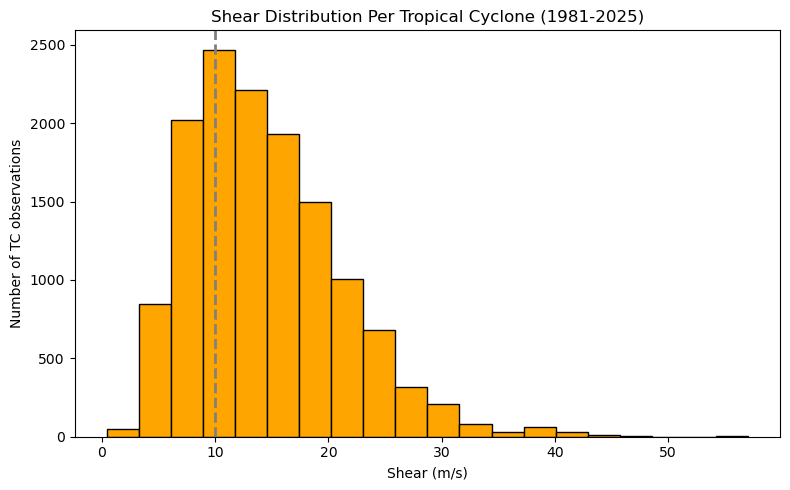

In [ ]:
# # histogram for ENTIRE ATLANTIC
# # keep June-October and observations with valid var
# merged_valid = merged[
#     merged["shear"].notna()
# ].copy()

# plt.figure(figsize=(8, 5))

# plt.hist(
#     merged_valid["shear"],
#     bins=20,
#     edgecolor="black",
#     color="orange"
# )

# # TC threshold
# plt.axvline(
#     10,
#     color="gray",
#     linestyle="--",
#     linewidth=2,
#     label="10"
# )

# plt.xlabel("Shear (m/s)")
# plt.ylabel("Number of TC observations")
# plt.title("Shear Distribution Per Tropical Cyclone (1981-2025)")

# plt.tight_layout()
# # plt.savefig("images/data_viz/thresholds/tc_shearTH_histogram_syclops_noaa_match.png")
# plt.show()


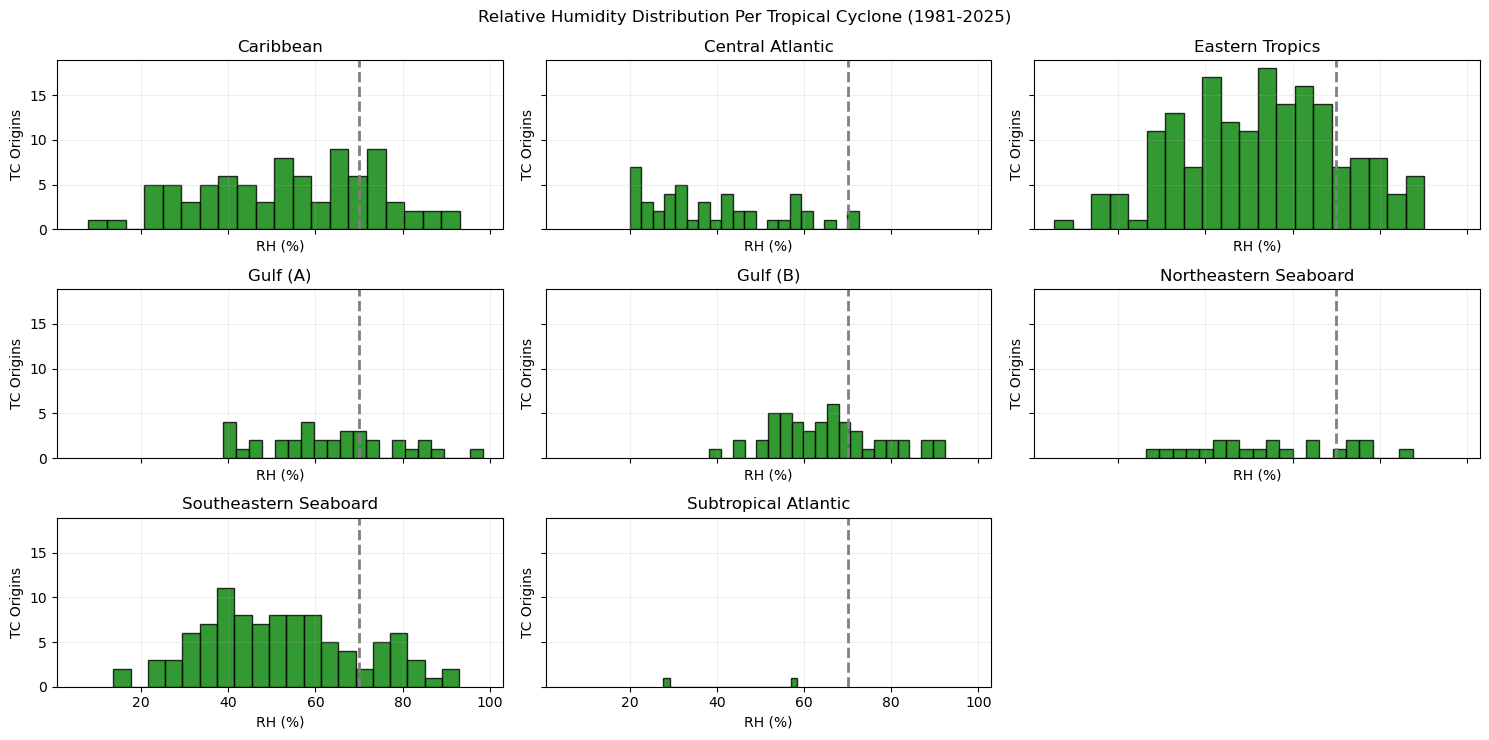

In [ ]:
# load merged table
ds = pd.read_csv("datasets/SyCLoPS/tc_sst+rhum600+shear_merged_table_1981-2025.csv")

# convert LAT and LON to a new column Points which contains (lon, lat) and convert to a geo data frame so we can filter using polygons
points = gpd.GeoDataFrame(
    ds, 
    geometry = gpd.points_from_xy(ds.LON, ds.LAT),
    crs = "EPSG:4326"
)

# print(points)

# filter points to North Atlantic
filtered = gpd.sjoin(
    points,
    basins[basins["basin name"] == "N Atlantic"],
    how = "inner",
    predicate = "within"
)

# drop columns we dont need
filtered = filtered[['TID', 'LON', 'LAT', 'ISOTIME', 'sst', 'rhum', 'shear', 'geometry']]

# join sub basins
sb = gpd.sjoin(
    filtered,
    sub_basins[['sub_basin_name', 'geometry']],
    how='left',
    predicate='intersects'
)

# print(sb)

# # plot histogram per sub basin
# filter out sub basins with low TCs
keep_subbasins = [
    "Caribbean",
    "Central Atlantic",
    "Eastern Tropics",
    "Gulf (A)",
    "Gulf (B)",
    "Northeastern Seaboard",
    "Southeastern Seaboard",
    "Subtropical Atlantic"
]

sb_filtered = sb[
    sb["sub_basin_name"].isin(keep_subbasins)
]

# Get the unique sub-basins
subbasins = sorted(sb_filtered["sub_basin_name"].dropna().unique())

# Create a grid of subplots
n = len(subbasins)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 2.5 * nrows),
    sharex=True,
    sharey=True
)

# Make axes easy to loop over
axes = np.atleast_1d(axes).flatten()

# Make one histogram per sub-basin
for ax, subbasin in zip(axes, subbasins):

    data = sb_filtered.loc[
        sb_filtered["sub_basin_name"] == subbasin,
        "rhum"
    ].dropna()

    ax.hist(
        data,
        bins=20,
        edgecolor="black",
        color="green",
        alpha=0.8
    )

    ax.axvline(
        70,
        color="gray",
        linestyle="--",
        linewidth=2,
        label="70%"
    )

    ax.set_title(subbasin)
    ax.set_xlabel("RH (%)")
    ax.set_ylabel("TC Origins")
    ax.grid(alpha=0.2)

# Hide unused subplot(s)
for ax in axes[len(subbasins):]:
    ax.set_visible(False)

plt.suptitle("Relative Humidity Distribution Per Tropical Cyclone (1981-2025)")
plt.tight_layout()
# plt.savefig("images/data_viz/thresholds/tcOrigins_rhTH_histogram_syclops_noaa_match_perSb.png")
plt.show()
